## LG SOC Prediction - Long Short Term Memory Networks (LSTM)
LG 18650HG2 Li-ion Battery Data - https://data.mendeley.com/datasets/cp3473x7xv/3

In [1]:
import os
import sys
import IPython
import IPython.display
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import collections
from datetime import datetime, timedelta

import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import LSTM
from keras.callbacks import EarlyStopping
from keras.layers.core import Dense
from tensorflow.keras import layers

from sklearn.preprocessing import MinMaxScaler
import pickle
import warnings
warnings.filterwarnings('ignore')

cell_type = "lg"
model_type = "lstm_model"
base_path = '../../'

sys.path.append(base_path)
from training import utils

panasonic_data_path = base_path + 'datasets/Panasonic_18650PF'
lg_data_path = base_path + 'datasets/LG_18650HG2'
pre_trained_path = base_path + 'pre-trained/' + cell_type + '_' + model_type

resample_1hz = False
vi_averages = True

## LG Test, Train Processing

In [2]:
lg_charge_cycles = ['Charge']

lg_train_temps = ['n10degC', '0degC', '10degC', '25degC']
lg_train_discharge_cycles = ['Mixed']

lg_test_temps = ['n10degC', '0degC', '10degC', '25degC']
lg_test_discharge_cycles = ['UDDS', 'HWFET', 'LA92', 'US06']

lg_train_files = utils.lg_get_files(lg_data_path, 
                                    lg_train_discharge_cycles, 
                                    lg_charge_cycles, 
                                    lg_train_temps)

lg_test_files = utils.lg_get_files(lg_data_path, 
                                   lg_test_discharge_cycles,
                                   lg_charge_cycles, 
                                   lg_test_temps)

lg_train, lg_train_norm = utils.lg_create_dataset(lg_train_files, 
                                                  lg_train_discharge_cycles, 
                                                  lg_charge_cycles, 
                                                  vi_averages, 
                                                  resample_1hz)

lg_test, lg_test_norm = utils.lg_create_dataset(lg_test_files, 
                                                lg_test_discharge_cycles, 
                                                lg_charge_cycles, 
                                                vi_averages, 
                                                resample_1hz)
# create lstm dataset
steps = 300

train_x, train_y = utils.create_lstm_dataset(lg_train_norm,steps)
test_x, test_y = utils.create_lstm_dataset(lg_test_norm,steps)

train_y = utils.keep_only_y_end(train_y, steps)
test_y = utils.keep_only_y_end(test_y, steps)

../../datasets/LG_18650HG2/25degC/551_Mixed1.csv 77227
../../datasets/LG_18650HG2/25degC/551_Mixed2.csv 79172
../../datasets/LG_18650HG2/25degC/552_Mixed3.csv 73827
../../datasets/LG_18650HG2/25degC/552_Mixed4.csv 80850
../../datasets/LG_18650HG2/25degC/552_Mixed5.csv 72184
../../datasets/LG_18650HG2/25degC/552_Mixed6.csv 78106
../../datasets/LG_18650HG2/25degC/552_Mixed7.csv 73235
../../datasets/LG_18650HG2/25degC/552_Mixed8.csv 85915
../../datasets/LG_18650HG2/10degC/567_Mixed1.csv 72329
../../datasets/LG_18650HG2/10degC/567_Mixed2.csv 77752
../../datasets/LG_18650HG2/10degC/571_Mixed4.csv 73929
../../datasets/LG_18650HG2/10degC/571_Mixed5.csv 67174
../../datasets/LG_18650HG2/10degC/571_Mixed6.csv 73921
../../datasets/LG_18650HG2/10degC/571_Mixed7.csv 69325
../../datasets/LG_18650HG2/10degC/571_Mixed8.csv 81422
../../datasets/LG_18650HG2/0degC/589_Mixed1.csv 67312
../../datasets/LG_18650HG2/0degC/589_Mixed2.csv 72303
../../datasets/LG_18650HG2/0degC/590_Mixed4.csv 68027
../../dataset

## LG Train, Test Stats

In [3]:
lg_train.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Time Stamp,,,,,,,,
Voltage,1766953.0,3.666106,0.262907,2.788130,3.495400,3.672890,3.861010,4.209560
Current,1766953.0,-1.327566,2.560378,-18.098280,-2.551540,-0.942460,-0.097060,6.004720
Temperature,1766953.0,7.852386,12.538952,-9.884900,-0.315480,9.359110,23.976150,26.289630
Power,1766953.0,-4.572944,8.942017,-50.875355,-9.204682,-3.438450,-0.385844,25.184354
Capacity,1766953.0,0.486652,0.268261,0.000000,0.269442,0.474609,0.717070,0.978041
Voltage Average,1766953.0,3.700793,0.227465,3.094400,3.521779,3.695029,3.890524,4.168740
Current Average,1766953.0,-1.289260,0.720794,-3.711826,-1.715167,-1.160927,-0.764838,1.225048
Power Average,1766953.0,-4.494775,2.448886,-11.434436,-5.985586,-4.120764,-2.685925,5.168611


In [4]:
lg_test.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Time Stamp,,,,,,,,
Voltage,1042865.0,3.677300,0.261296,2.786280,3.496750,3.688530,3.884600,4.200460
Current,1042865.0,-1.099719,2.359092,-18.070180,-2.196520,-0.625750,-0.084280,6.002170
Temperature,1042865.0,6.917488,12.071449,-10.095220,-0.420630,9.148790,23.765830,26.815430
Power,1042865.0,-3.778445,8.247301,-50.866963,-7.929746,-2.318157,-0.321071,25.181295
Capacity,1042865.0,0.483628,0.267320,0.000000,0.258047,0.493902,0.713217,0.955909
Voltage Average,1042865.0,3.704194,0.229102,3.049703,3.523453,3.715520,3.899700,4.110379
Current Average,1042865.0,-1.097604,0.727766,-3.810302,-1.336604,-0.868705,-0.523978,-0.309855
Power Average,1042865.0,-3.823480,2.438030,-11.886129,-4.540661,-3.073495,-1.887389,-1.233941


## LG Dataset Figures, Distribution


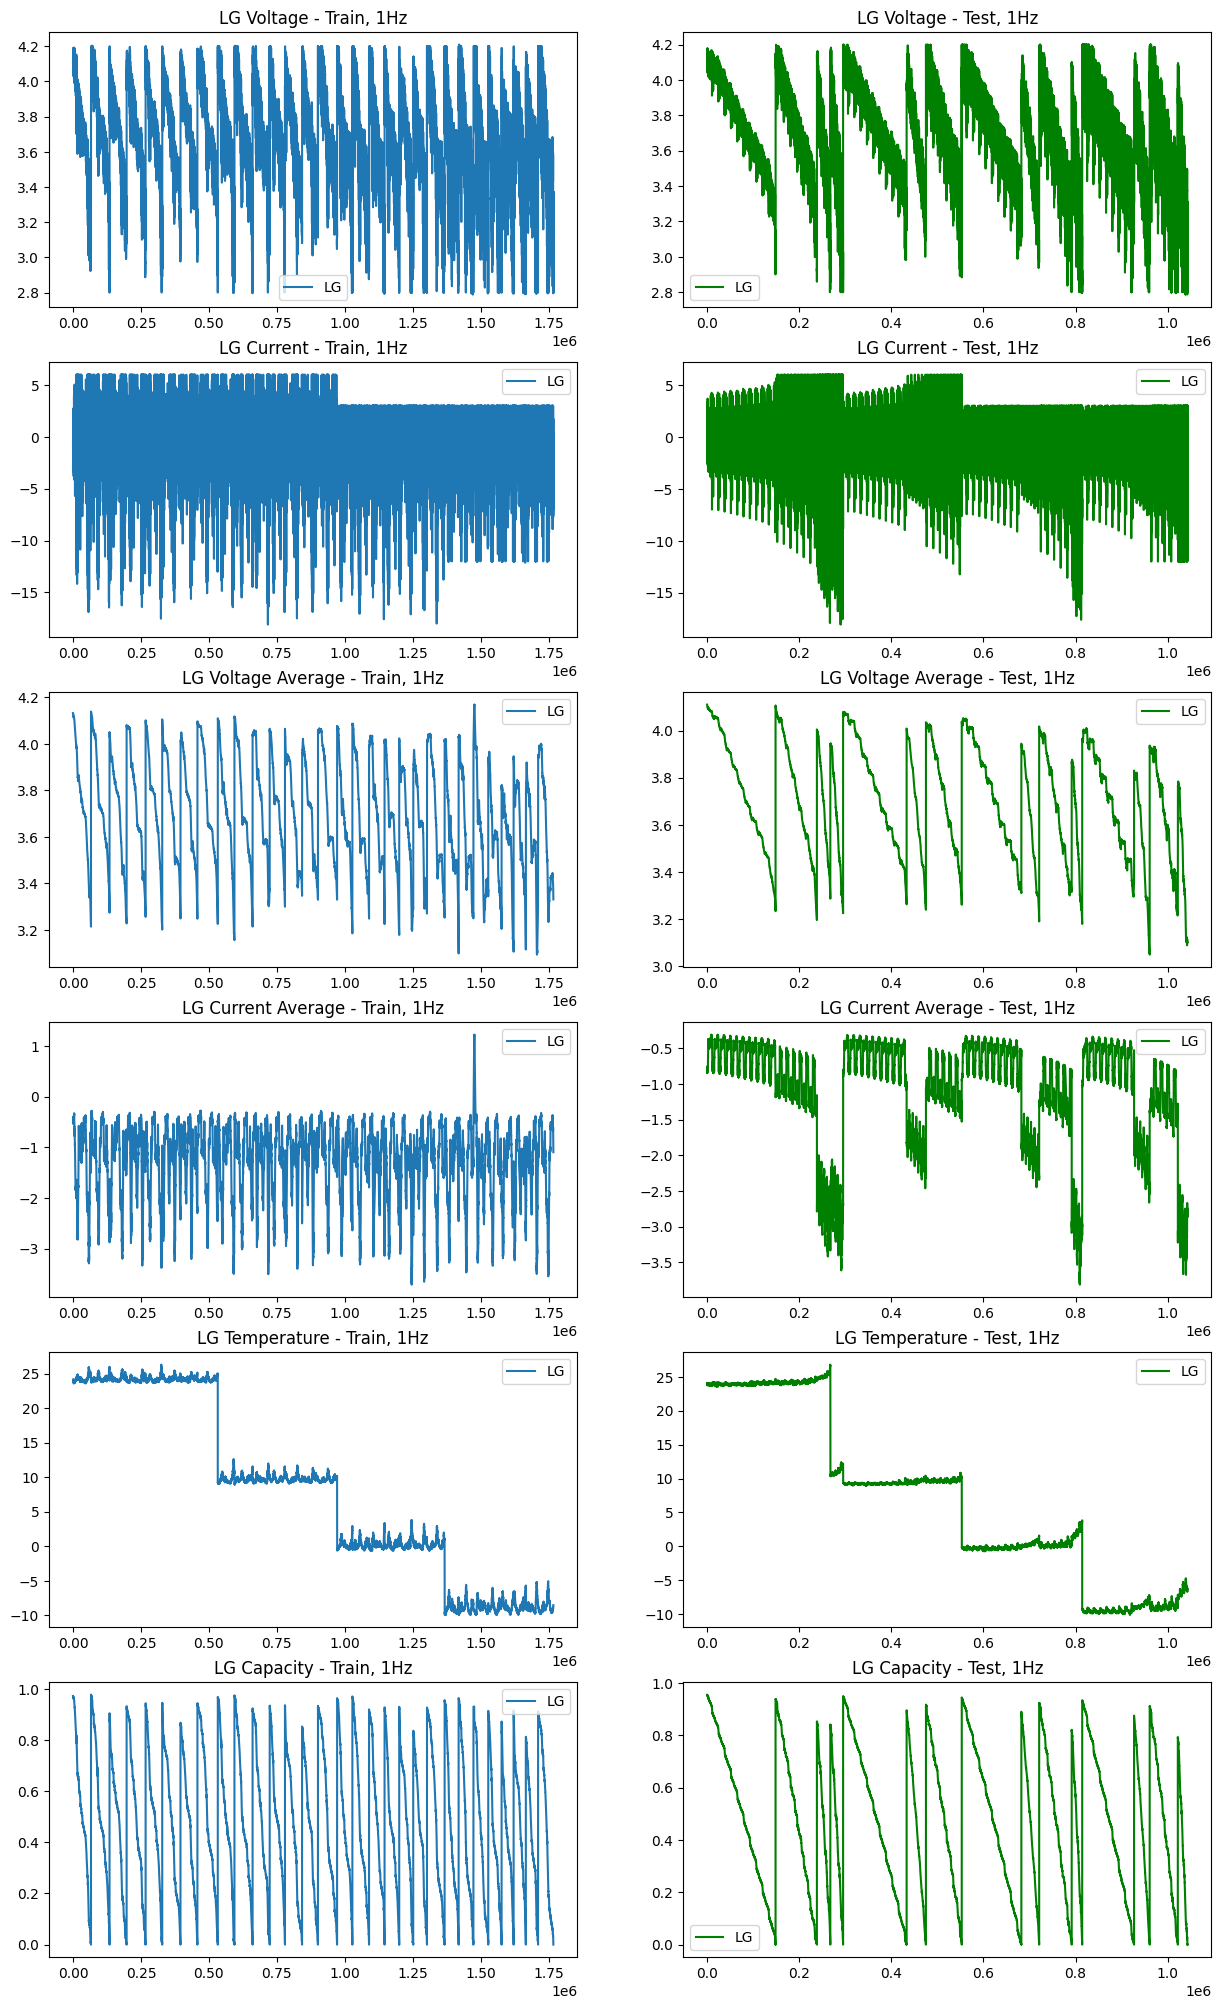

In [5]:
plot_cols = ['Voltage', 'Current', 'Voltage Average', 'Current Average', 'Temperature', 'Capacity']

fig, axs = plt.subplots(nrows=len(plot_cols), ncols=2, figsize=(15, 25))

for i, col in enumerate(plot_cols):
    axs[i, 0].plot(lg_train[col], label='LG')
    axs[i, 0].set_title(f'LG {col} - Train, 1Hz')
    axs[i, 0].legend()
    
    axs[i, 1].plot(lg_test[col], label='LG', color="green")
    axs[i, 1].set_title(f'LG {col} - Test, 1Hz')
    axs[i, 1].legend()

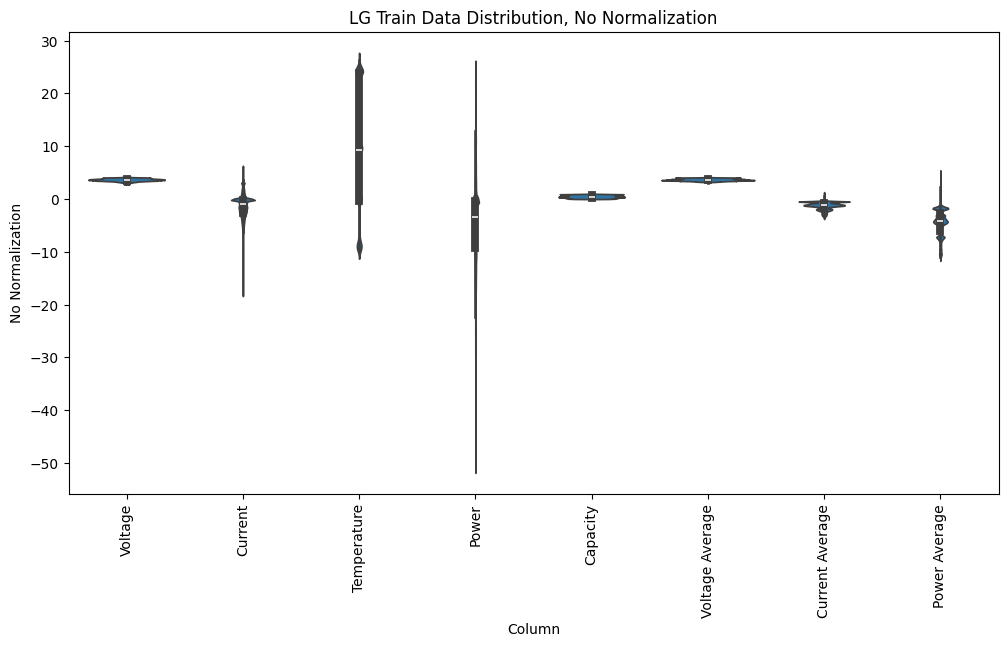

In [6]:
df_std = lg_train.melt(var_name='Column', value_name='No Normalization')
plt.figure(figsize=(12, 6))
ax = sns.violinplot(x='Column', y='No Normalization', data=df_std)
_ = ax.set_xticklabels(lg_train.keys(), rotation=90)
_ = ax.set_title(label='LG Train Data Distribution, No Normalization')

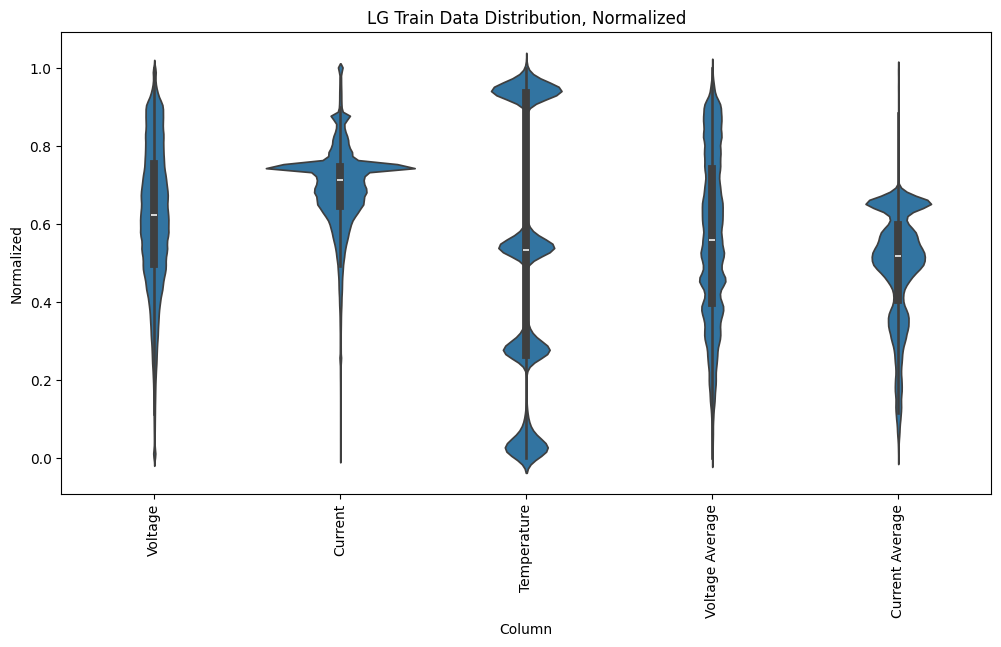

In [7]:
df_std = lg_train_norm.melt(var_name='Column', value_name='Normalized')
plt.figure(figsize=(12, 6))
ax = sns.violinplot(x='Column', y='Normalized', data=df_std)
_ = ax.set_xticklabels(lg_train_norm.keys(), rotation=90)
_ = ax.set_title(label='LG Train Data Distribution, Normalized')

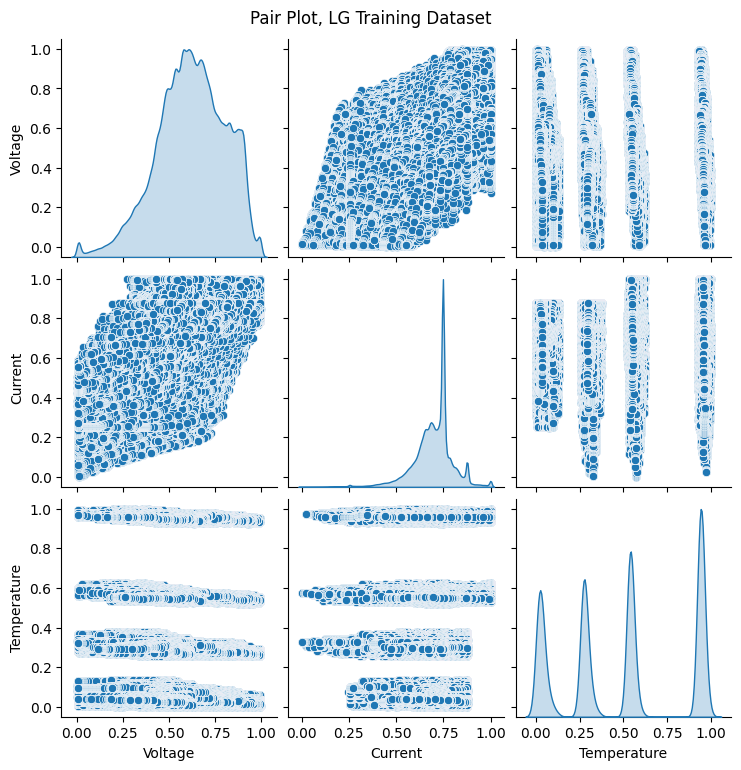

In [8]:
# ax = sns.pairplot(lg_train_norm[['Voltage', 'Current', 'Power', 'Temperature', 'Capacity']], diag_kind='kde')
# ax.fig.suptitle("Pair Plot, LG Training Dataset", y = 1.01) 
import seaborn as sns
import matplotlib.pyplot as plt

# List of columns you want to plot
cols_to_plot = ['Voltage', 'Current', 'Power', 'Temperature', 'Capacity']

# Keep only columns that exist in the DataFrame
cols_existing = [col for col in cols_to_plot if col in lg_train_norm.columns]

# Check if we have any columns to plot
if len(cols_existing) > 0:
    ax = sns.pairplot(lg_train_norm[cols_existing], diag_kind='kde')
    ax.fig.suptitle("Pair Plot, LG Training Dataset", y=1.02)
    plt.show()
else:
    print("None of the specified columns exist in the DataFrame.")

## LSTM MODEL TRAINING


In [9]:
# LSTM model architecture - https://github.com/KeiLongW/battery-state-estimation
opt = tf.keras.optimizers.Adam(lr=0.00001)

lstm_model = Sequential()
lstm_model.add(LSTM(256, activation='selu',
                    return_sequences=True,
                    input_shape=(train_x.shape[1], train_x.shape[2])))
lstm_model.add(LSTM(256, activation='selu', return_sequences=False))
lstm_model.add(Dense(256, activation='selu'))
lstm_model.add(Dense(128, activation='selu'))
lstm_model.add(Dense(1, activation='linear'))
lstm_model.summary()

lstm_model.compile(optimizer=opt, loss='huber', metrics=['mse', 'mae', 'mape', tf.keras.metrics.RootMeanSquaredError(name='rmse')])

es = EarlyStopping(monitor='val_loss', patience=50)

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 300, 256)          268288    
                                                                 
 lstm_1 (LSTM)               (None, 256)               525312    
                                                                 
 dense (Dense)               (None, 256)               65792     
                                                                 
 dense_1 (Dense)             (None, 128)               32896     
                                                                 
 dense_2 (Dense)             (None, 1)                 129       
                                                                 
Total params: 892,417
Trainable params: 892,417
Non-trainable params: 0
_________________________________________________________________


In [13]:
history = lstm_model.fit(
    train_x, 
    train_y, 
    epochs=75, batch_size=32, 
    verbose=1, validation_split=0.2,
    callbacks = [es])

Epoch 1/75
148/148 [==============================] - 597s 4s/step - loss: 0.0383 - mse: 0.0816 - mae: 0.1412 - mape: 406.8381 - rmse: 0.2856 - val_loss: 0.0088 - val_mse: 0.0177 - val_mae: 0.1014 - val_mape: 710.1780 - val_rmse: 0.1330
Epoch 2/75
148/148 [==============================] - 585s 4s/step - loss: 0.0024 - mse: 0.0048 - mae: 0.0339 - mape: 357.3070 - rmse: 0.0690 - val_loss: 0.0049 - val_mse: 0.0098 - val_mae: 0.0642 - val_mape: 750.4257 - val_rmse: 0.0991
Epoch 3/75
148/148 [==============================] - 759s 5s/step - loss: 0.0021 - mse: 0.0043 - mae: 0.0298 - mape: 361.6805 - rmse: 0.0654 - val_loss: 0.0039 - val_mse: 0.0078 - val_mae: 0.0511 - val_mape: 744.1138 - val_rmse: 0.0884
Epoch 4/75
148/148 [==============================] - 638s 4s/step - loss: 0.0020 - mse: 0.0040 - mae: 0.0264 - mape: 355.2161 - rmse: 0.0633 - val_loss: 0.0036 - val_mse: 0.0071 - val_mae: 0.0463 - val_mape: 756.2567 - val_rmse: 0.0845
Epoch 5/75
148/148 [==============================] 

## SAVE MODEL, EVALUATE

In [14]:
# Save as SavedModel (folder format)
lstm_model.save(pre_trained_path)
print(f"Model saved in TensorFlow SavedModel format at: {pre_trained_path}")

# Save as .h5 (Flask / lightweight format)
h5_path = pre_trained_path + ".h5"
lstm_model.save(h5_path)
print(f"Model also saved in H5 format at: {h5_path}")

# Assuming train_x is 3D: (samples, timesteps, features)
train_x_reshaped = train_x.reshape((train_x.shape[0], -1))  # flatten 2D for scaler
train_scaler = MinMaxScaler()
train_x_scaled = train_scaler.fit_transform(train_x_reshaped)

scaler_path = pre_trained_path + "_scaler.pkl"
with open(scaler_path, "wb") as f:
    pickle.dump(train_scaler, f)  # train_scaler = scaler.fit(train_features)


INFO:tensorflow:Assets written to: ../../pre-trained/lg_lstm_model\assets
Model saved in TensorFlow SavedModel format at: ../../pre-trained/lg_lstm_model
Model also saved in H5 format at: ../../pre-trained/lg_lstm_model.h5


In [15]:
hist = pd.DataFrame(history.history)
hist['epoch'] = history.epoch
hist.tail()

,loss,mse,mae,mape,rmse,val_loss,val_mse,val_mae,val_mape,val_rmse,epoch
70,0.000872,0.001745,0.020709,289.959259,0.041768,0.002965,0.005930,0.034655,799.595642,0.077008,70
71,0.000872,0.001744,0.018055,284.508484,0.041756,0.002864,0.005727,0.034524,798.314331,0.075679,71
72,0.001177,0.002353,0.022667,316.880890,0.048512,0.002563,0.005125,0.033416,747.237671,0.071591,72
73,0.000836,0.001672,0.016863,294.269714,0.040890,0.003010,0.006021,0.039158,786.815430,0.077595,73
74,0.000822,0.001645,0.016614,288.259338,0.040554,0.002960,0.005921,0.036539,782.583679,0.076946,74


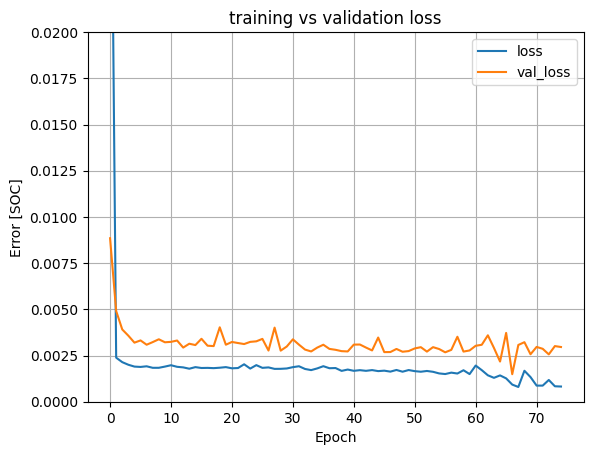

In [16]:
def plot_loss(history):
    plt.plot(history.history['loss'], label='loss')
    plt.plot(history.history['val_loss'], label='val_loss')
    plt.ylim([0, 0.02])
    plt.xlabel('Epoch') 
    plt.ylabel('Error [SOC]')
    plt.title('training vs validation loss')
    plt.legend()
    plt.grid(True)
    
plot_loss(history)

109/109 - 137s - loss: 0.0020 - mse: 0.0039 - mae: 0.0439 - mape: 69.0639 - rmse: 0.0625 - 137s/epoch - 1s/step
109/109 [==============================] - 126s 1s/step


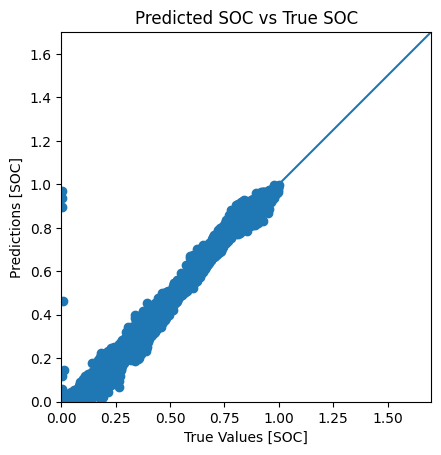

In [17]:
test_results = lstm_model.evaluate(test_x, test_y, verbose=2)
test_predictions = lstm_model.predict(test_x).flatten()

a = plt.axes(aspect='equal')
plt.scatter(test_y, test_predictions)
plt.xlabel('True Values [SOC]')
plt.ylabel('Predictions [SOC]')
lims = [0, 1.7]
plt.xlim(lims)
plt.ylim(lims)
plt.title('Predicted SOC vs True SOC')
_ = plt.plot(lims, lims)

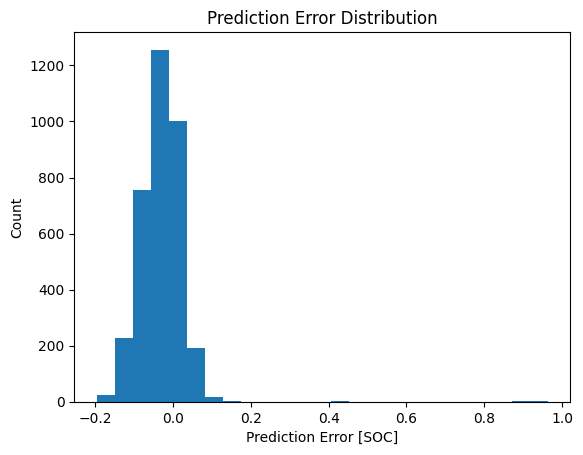

In [18]:
error = test_predictions - test_y.flatten()
plt.hist(error, bins=25)
plt.xlabel('Prediction Error [SOC]')
plt.title('Prediction Error Distribution')
_ = plt.ylabel('Count')

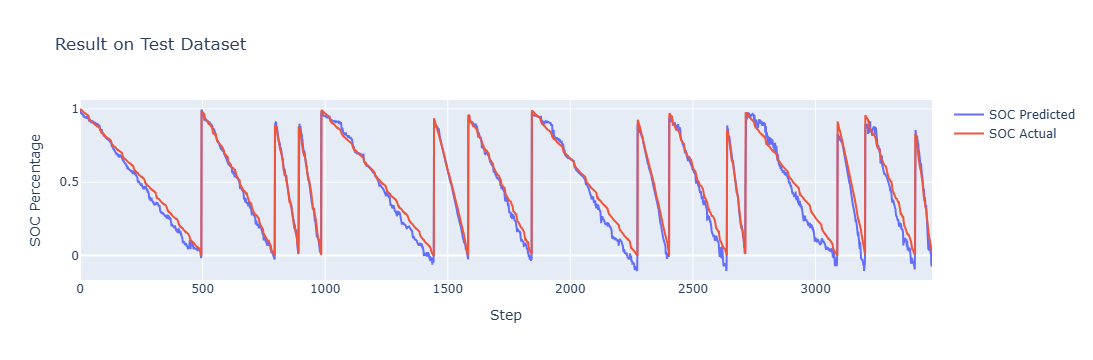

In [19]:
import plotly.graph_objects as go

cycle_num = 0
steps_num = 100000
step_index = np.arange(cycle_num*steps_num, (cycle_num+1)*steps_num)

fig = go.Figure()
fig.add_trace(go.Scatter(x=step_index, y=test_predictions.flatten()[cycle_num*steps_num:(cycle_num+1)*steps_num],
                    mode='lines', name='SOC Predicted'))
fig.add_trace(go.Scatter(x=step_index, y=test_y.flatten()[cycle_num*steps_num:(cycle_num+1)*steps_num],
                    mode='lines', name='SOC Actual'))
fig.update_layout(title='Result on Test Dataset',
                  xaxis_title='Step',
                  yaxis_title='SOC Percentage')
fig.show()

In [23]:
print(train_x.shape)

(5889, 300, 5)


In [32]:
print(lstm_model.input_shape)

(None, 300, 5)
